## Step X — Add and Harmonize Dental-Dataset-roboflow & Roboflow-dataset
We will add both the Dental-Dataset-roboflow (4 classes) and Roboflow-dataset (6 classes) to the pipeline, harmonizing their class names and structure for unified training.

In [ ]:
# Paths to both datasets
from pathlib import Path
dental_roboflow = Path('Dental-Dataset-roboflow')
roboflow_dataset = Path('Roboflow-dataset')

# Read class names from both data.yaml files
import yaml
with open(dental_roboflow / 'data.yaml') as f:
    dental_classes = yaml.safe_load(f)['names']
with open(roboflow_dataset / 'data.yaml') as f:
    roboflow_classes = yaml.safe_load(f)['names']
print('Dental-Dataset-roboflow classes:', dental_classes)
print('Roboflow-dataset classes:', roboflow_classes)

# Harmonize class names (example: unify capitalization, spelling, etc.)
def normalize_class(name):
    return name.strip().lower().replace(' ', '_')

dental_classes_norm = [normalize_class(c) for c in dental_classes]
roboflow_classes_norm = [normalize_class(c) for c in roboflow_classes]

print('Normalized Dental-Dataset-roboflow:', dental_classes_norm)
print('Normalized Roboflow-dataset:', roboflow_classes_norm)

# Check for congruence
if set(dental_classes_norm).issubset(set(roboflow_classes_norm)) or set(roboflow_classes_norm).issubset(set(dental_classes_norm)):
    print('Datasets are congruent or can be merged directly.')
else:
    print('Datasets have different classes. Manual mapping or merging required.')

# SmileGuard — Dental Detection Training Pipeline

## Pipeline Overview
1. **Download** — Kaggle 6-Class Intraoral Disease Dataset
2. **Convert** — DatasetNinja annotations → YOLO format
3. **Convert** — Kaggle classification images → YOLO format (full-image bboxes)
4. **Merge** — Combine both datasets into one unified set
5. **Validate** — Verify all files are in place, check class mappings
6. **Balance Check** — Analyze class distribution & detect over/under-sampling
7. **Train** — YOLOv8 model training
8. **Evaluate** — Model performance metrics
9. **Inference** — DentalDetector class + visualization
10. **API** — Flask endpoint for integration

## Step 1 — Download Kaggle Dataset
Download the [6-Class Intraoral Disease Dataset](https://www.kaggle.com/datasets/sehrishnoords/6-class-intraoral-disease-dataset) (classification: Calculus, Caries, Gingivitis, Hypodontia, Mouth Ulcer, Tooth Discoloration).

In [4]:
import kagglehub
from pathlib import Path

# Download the 6-class intraoral disease dataset
kaggle_path = kagglehub.dataset_download("sehrishnoords/6-class-intraoral-disease-dataset")
KAGGLE_ROOT = Path(kaggle_path) / "6_classs_Intraoral_dental_disease"

print(f"✅ Downloaded to: {kaggle_path}")
print(f"   Disease folder: {KAGGLE_ROOT}")

# Quick summary
import os
for d in sorted(KAGGLE_ROOT.iterdir()):
    if d.is_dir():
        count = len([f for f in d.iterdir() if f.is_file()])
        print(f"   {d.name:<25} {count:>5} images")

✅ Downloaded to: C:\Users\PerezKylerLee(Studen\.cache\kagglehub\datasets\sehrishnoords\6-class-intraoral-disease-dataset\versions\1
   Disease folder: C:\Users\PerezKylerLee(Studen\.cache\kagglehub\datasets\sehrishnoords\6-class-intraoral-disease-dataset\versions\1\6_classs_Intraoral_dental_disease
   Calculus                   1512 images
   caries                     2601 images
   Gingivitis                 2349 images
   hypodontia                 1515 images
   mouth ulcer                2806 images
   tooth_discoloration        2017 images


## Step 2 — Convert DatasetNinja → YOLO Format
Convert the `dentalai-DatasetNinja` annotations (JSON polygon format) into YOLO bounding-box labels.
Classes: `tooth`(0), `caries`(1), `cavity`(2), `crack`(3)

In [5]:
import shutil, os, json
from pathlib import Path

SRC_DIR  = Path("./dentalai-DatasetNinja")
DEST_DIR = Path("./yolo_dataset")

classes = {'tooth': 0, 'Tooth': 0, 'caries': 1, 'Caries': 1,
           'cavity': 2, 'Cavity': 2, 'crack': 3, 'Crack': 3}
CLASS_NAMES = ['tooth', 'caries', 'cavity', 'crack']

# Setup directories
for split in ['train', 'val', 'test']:
    (DEST_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (DEST_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

# Write data.yaml with absolute paths
DEST_ABS = str(DEST_DIR.resolve())
yaml_content = f"""train: {DEST_ABS}/train/images
val: {DEST_ABS}/val/images
test: {DEST_ABS}/test/images

nc: {len(CLASS_NAMES)}
names: {CLASS_NAMES}
"""
(DEST_DIR / "data.yaml").write_text(yaml_content)

# Convert
dirs_map = {"train": "train", "valid": "val", "test": "test"}
total_converted = 0
skipped_labels = set()

for src_folder, dest_folder in dirs_map.items():
    src_img = SRC_DIR / src_folder / "img"
    src_ann = SRC_DIR / src_folder / "ann"
    if not src_img.exists():
        print(f"⚠️  Skipping '{src_folder}' — not found")
        continue

    json_files = [f for f in os.listdir(src_ann) if f.endswith('.json')]
    print(f"Processing {src_folder}: {len(json_files)} annotations...")

    for jf in json_files:
        with open(src_ann / jf) as f:
            data = json.load(f)
        img_h, img_w = data['size']['height'], data['size']['width']
        yolo_lines = []
        for obj in data['objects']:
            label = obj['classTitle']
            if label not in classes:
                skipped_labels.add(label)
                continue
            cid = classes[label]
            pts = obj['points']['exterior']
            xs, ys = [p[0] for p in pts], [p[1] for p in pts]
            x_min, x_max = max(0, min(xs)), min(img_w, max(xs))
            y_min, y_max = max(0, min(ys)), min(img_h, max(ys))
            bw, bh = x_max - x_min, y_max - y_min
            if bw <= 0 or bh <= 0:
                continue
            xc, yc = x_min + bw/2, y_min + bh/2
            yolo_lines.append(f"{cid} {xc/img_w:.6f} {yc/img_h:.6f} {bw/img_w:.6f} {bh/img_h:.6f}")

        if yolo_lines:
            stem = Path(jf).stem            # "image.jpg" from "image.jpg.json"
            img_name = stem                  # image filename
            lbl_stem = Path(stem).stem       # "image" from "image.jpg"
            (DEST_DIR / dest_folder / "labels" / f"{lbl_stem}.txt").write_text("\n".join(yolo_lines))
            img_src = src_img / img_name
            if img_src.exists():
                shutil.copy(img_src, DEST_DIR / dest_folder / "images" / img_name)
                total_converted += 1

if skipped_labels:
    print(f"⚠️  Skipped unknown labels: {skipped_labels}")
print(f"\n✅ DatasetNinja → YOLO: {total_converted} images converted to {DEST_DIR}")

Processing train: 1991 annotations...
Processing valid: 254 annotations...
Processing test: 250 annotations...

✅ DatasetNinja → YOLO: 2495 images converted to yolo_dataset


## Step 3 — Convert Kaggle Classification → YOLO Format
The Kaggle dataset is **classification-only** (folder-per-class, no bounding boxes). We convert it to YOLO detection format using **full-image bounding boxes** (`0.5 0.5 1.0 1.0`).

**Class mapping** — only `caries` overlaps with the existing dataset; other Kaggle classes are added as new disease types:

| Kaggle Class | → Unified ID | Note |
|---|---|---|
| caries | 1 | Overlaps with DatasetNinja |
| Calculus | 4 | New |
| Gingivitis | 5 | New |
| hypodontia | 6 | New |
| mouth ulcer | 7 | New |
| tooth discoloration | 8 | New |

In [6]:
import shutil, random
from pathlib import Path

# ── Config ───────────────────────────────────────────────────────────────
KAGGLE_ROOT = Path(r"C:\Users\PerezKylerLee(Studen\.cache\kagglehub\datasets\sehrishnoords\6-class-intraoral-disease-dataset\versions\1\6_classs_Intraoral_dental_disease")
KAGGLE_YOLO = Path("./kaggle_yolo")       # Intermediate YOLO-format output
VALID_EXTS  = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Map Kaggle folder names → unified class IDs
# IDs 0-3 match the existing DatasetNinja classes
KAGGLE_CLASS_MAP = {
    "caries":              1,   # overlaps with existing
    "Calculus":            4,   # new
    "Gingivitis":          5,   # new
    "hypodontia":          6,   # new
    "mouth ulcer":         7,   # new
    "tooth_discoloration": 8,   # new
}

SPLIT_RATIOS = {"train": 0.80, "val": 0.15, "test": 0.05}

# ── Setup output dirs ────────────────────────────────────────────────────
for split in SPLIT_RATIOS:
    (KAGGLE_YOLO / split / "images").mkdir(parents=True, exist_ok=True)
    (KAGGLE_YOLO / split / "labels").mkdir(parents=True, exist_ok=True)

# ── Convert each class folder ────────────────────────────────────────────
random.seed(42)
stats = {}

for folder_name, class_id in KAGGLE_CLASS_MAP.items():
    cls_dir = KAGGLE_ROOT / folder_name
    if not cls_dir.exists():
        print(f"⚠️  Folder not found: {cls_dir}")
        continue

    images = [f for f in cls_dir.iterdir() if f.is_file() and f.suffix.lower() in VALID_EXTS]
    random.shuffle(images)

    n = len(images)
    n_train = int(n * SPLIT_RATIOS["train"])
    n_val   = int(n * SPLIT_RATIOS["val"])

    splits = {
        "train": images[:n_train],
        "val":   images[n_train:n_train + n_val],
        "test":  images[n_train + n_val:],
    }

    split_counts = {}
    for split_name, split_imgs in splits.items():
        for i, img_path in enumerate(split_imgs):
            # Unique name to avoid collisions
            new_stem = f"kaggle_{folder_name.replace(' ', '_')}_{i:04d}"
            new_ext  = img_path.suffix.lower()

            # Copy image
            shutil.copy(img_path, KAGGLE_YOLO / split_name / "images" / f"{new_stem}{new_ext}")

            # Write full-image bbox label: class_id 0.5 0.5 1.0 1.0
            (KAGGLE_YOLO / split_name / "labels" / f"{new_stem}.txt").write_text(
                f"{class_id} 0.500000 0.500000 1.000000 1.000000"
            )

        split_counts[split_name] = len(split_imgs)

    stats[folder_name] = {"id": class_id, "total": n, **split_counts}
    print(f"  ✅ {folder_name:<25} → class {class_id}  |  train={split_counts['train']}  val={split_counts['val']}  test={split_counts['test']}")

print(f"\n✅ Kaggle → YOLO: {sum(s['total'] for s in stats.values())} images converted to {KAGGLE_YOLO}")

  ✅ caries                    → class 1  |  train=2080  val=390  test=131
  ✅ Calculus                  → class 4  |  train=1209  val=226  test=77
  ✅ Gingivitis                → class 5  |  train=1879  val=352  test=118
  ✅ hypodontia                → class 6  |  train=1212  val=227  test=76
  ✅ mouth ulcer               → class 7  |  train=2244  val=420  test=142
  ✅ tooth_discoloration       → class 8  |  train=1613  val=302  test=102

✅ Kaggle → YOLO: 12800 images converted to kaggle_yolo


## Step 4 — Merge Datasets
Merge the two YOLO datasets (`yolo_dataset` from DatasetNinja + `kaggle_yolo` from Kaggle) into a single unified `yolo_dataset_merged/` with 9 classes.

In [7]:
import shutil, os
from pathlib import Path

# ── Config ───────────────────────────────────────────────────────────────
OUTPUT_DIR = Path("./yolo_dataset_merged")

UNIFIED_NAMES = [
    'tooth',               # 0 — from DatasetNinja
    'caries',              # 1 — from both
    'cavity',              # 2 — from DatasetNinja
    'crack',               # 3 — from DatasetNinja
    'calculus',            # 4 — from Kaggle
    'gingivitis',          # 5 — from Kaggle
    'hypodontia',          # 6 — from Kaggle
    'mouth_ulcer',         # 7 — from Kaggle
    'tooth_discoloration', # 8 — from Kaggle
]

DATASET_SOURCES = [
    {"path": Path("./yolo_dataset"),  "remap": None},   # Already uses IDs 0-3
    {"path": Path("./kaggle_yolo"),   "remap": None},   # Already uses IDs 1,4-8
]

# ── Setup output ─────────────────────────────────────────────────────────
for split in ['train', 'val', 'test']:
    (OUTPUT_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

# ── Merge loop ───────────────────────────────────────────────────────────
global_idx = 0

for ds in DATASET_SOURCES:
    ds_path = ds["path"]
    if not ds_path.exists():
        print(f"⚠️  Not found: {ds_path} — skipping")
        continue

    print(f"\n📂 Merging: {ds_path}")
    ds_count = 0

    for split_src in ['train', 'val', 'test']:
        img_dir = ds_path / split_src / "images"
        lbl_dir = ds_path / split_src / "labels"
        if not img_dir.exists():
            continue

        images = sorted(img_dir.glob("*"))
        for img_path in images:
            if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
                continue

            label_path = lbl_dir / (img_path.stem + ".txt")
            if not label_path.exists():
                continue

            # Copy with unique name
            new_name = f"merged_{global_idx:06d}"
            shutil.copy(img_path, OUTPUT_DIR / split_src / "images" / f"{new_name}{img_path.suffix}")
            shutil.copy(label_path, OUTPUT_DIR / split_src / "labels" / f"{new_name}.txt")
            global_idx += 1
            ds_count += 1

    print(f"   Copied {ds_count} samples")

# ── Write data.yaml ──────────────────────────────────────────────────────
out_abs = str(OUTPUT_DIR.resolve())
yaml_content = f"""train: {out_abs}/train/images
val: {out_abs}/val/images
test: {out_abs}/test/images

nc: {len(UNIFIED_NAMES)}
names: {UNIFIED_NAMES}
"""
(OUTPUT_DIR / "data.yaml").write_text(yaml_content)

# ── Summary ──────────────────────────────────────────────────────────────
print(f"\n✅ Merged dataset: {OUTPUT_DIR}")
print(f"   Total samples: {global_idx}")
print(f"   Classes ({len(UNIFIED_NAMES)}): {UNIFIED_NAMES}")
for split in ['train', 'val', 'test']:
    n_img = len(list((OUTPUT_DIR / split / "images").glob("*")))
    n_lbl = len(list((OUTPUT_DIR / split / "labels").glob("*.txt")))
    print(f"   {split:>5}: {n_img} images, {n_lbl} labels")


📂 Merging: yolo_dataset
   Copied 2495 samples

📂 Merging: kaggle_yolo
   Copied 12800 samples

✅ Merged dataset: yolo_dataset_merged
   Total samples: 15295
   Classes (9): ['tooth', 'caries', 'cavity', 'crack', 'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration']
   train: 12228 images, 12228 labels
     val: 2171 images, 2171 labels
    test: 896 images, 896 labels


## Step 5 — Validate Merged Dataset
Verify all files are in place: every image has a label, every label has an image, all class IDs are valid, bounding boxes are properly normalized, and `data.yaml` is correct.

In [8]:
import yaml
from pathlib import Path
from collections import defaultdict

MERGED_DIR = Path("./yolo_dataset_merged")
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# ── 1. Check data.yaml ──────────────────────────────────────────────────
print("=" * 65)
print("1. DATA.YAML CHECK")
print("=" * 65)
yaml_path = MERGED_DIR / "data.yaml"
assert yaml_path.exists(), f"❌ data.yaml not found at {yaml_path}"

with open(yaml_path) as f:
    config = yaml.safe_load(f)

NUM_CLASSES   = config["nc"]
CLASS_NAMES   = config["names"]
print(f"  nc:    {NUM_CLASSES}")
print(f"  names: {CLASS_NAMES}")
print(f"  train: {config['train']}")
print(f"  val:   {config['val']}")
print(f"  test:  {config['test']}")

assert NUM_CLASSES == len(CLASS_NAMES), f"❌ nc={NUM_CLASSES} ≠ len(names)={len(CLASS_NAMES)}"
print("  ✅ data.yaml is consistent.\n")

# ── 2. File pairing per split ────────────────────────────────────────────
print("=" * 65)
print("2. IMAGE ↔ LABEL PAIRING")
print("=" * 65)

all_ok = True
total_images = 0
total_labels = 0

for split in ['train', 'val', 'test']:
    img_dir = MERGED_DIR / split / "images"
    lbl_dir = MERGED_DIR / split / "labels"

    imgs = {f.stem for f in img_dir.iterdir() if f.suffix.lower() in VALID_EXTS} if img_dir.exists() else set()
    lbls = {f.stem for f in lbl_dir.glob("*.txt")} if lbl_dir.exists() else set()

    imgs_no_lbl = imgs - lbls
    lbls_no_img = lbls - imgs
    paired      = imgs & lbls

    total_images += len(imgs)
    total_labels += len(lbls)

    status = "✅" if (not imgs_no_lbl and not lbls_no_img) else "⚠️"
    print(f"  {split:>5}: {len(paired)} paired  |  {len(imgs_no_lbl)} imgs missing labels  |  {len(lbls_no_img)} labels missing imgs  {status}")

    if imgs_no_lbl:
        all_ok = False
        for name in sorted(imgs_no_lbl)[:3]:
            print(f"         missing label: {name}")
    if lbls_no_img:
        all_ok = False
        for name in sorted(lbls_no_img)[:3]:
            print(f"         missing image: {name}")

if all_ok:
    print("  ✅ All files properly paired.\n")
else:
    print("  ⚠️  Some pairing issues found.\n")

# ── 3. Label format validation ───────────────────────────────────────────
print("=" * 65)
print("3. LABEL FORMAT VALIDATION")
print("=" * 65)

issues_count = 0
class_counts  = defaultdict(int)
total_annots  = 0
bad_examples  = []

for split in ['train', 'val', 'test']:
    lbl_dir = MERGED_DIR / split / "labels"
    if not lbl_dir.exists():
        continue

    for lbl_file in sorted(lbl_dir.glob("*.txt")):
        file_issues = []
        for i, line in enumerate(lbl_file.read_text().strip().splitlines(), 1):
            parts = line.strip().split()
            if not parts:
                continue
            if len(parts) != 5:
                file_issues.append(f"Line {i}: expected 5 values, got {len(parts)}")
                continue
            try:
                cid = int(parts[0])
            except ValueError:
                file_issues.append(f"Line {i}: class_id '{parts[0]}' not integer")
                continue

            if cid < 0 or cid >= NUM_CLASSES:
                file_issues.append(f"Line {i}: class_id {cid} out of range [0, {NUM_CLASSES-1}]")

            class_counts[cid] += 1
            total_annots += 1

            for j, coord_name in zip(range(1, 5), ["x_center", "y_center", "width", "height"]):
                try:
                    val = float(parts[j])
                    if val < 0.0 or val > 1.0:
                        file_issues.append(f"Line {i}: {coord_name}={val:.4f} outside [0,1]")
                except ValueError:
                    file_issues.append(f"Line {i}: {coord_name} not a float")

        if file_issues:
            issues_count += 1
            if len(bad_examples) < 3:
                bad_examples.append((lbl_file.name, file_issues[:3]))

if bad_examples:
    for fname, errs in bad_examples:
        print(f"  ⚠️  {fname}:")
        for e in errs:
            print(f"       {e}")

if issues_count == 0:
    print(f"  ✅ All labels valid YOLO format ({total_annots} total annotations).")
else:
    print(f"  ⚠️  {issues_count} label files with issues.")

# ── 4. Class coverage ────────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print("4. CLASS COVERAGE")
print("=" * 65)
found_ids = sorted(class_counts.keys())
expected_ids = list(range(NUM_CLASSES))
missing_ids  = set(expected_ids) - set(found_ids)

for cid in expected_ids:
    name  = CLASS_NAMES[cid] if cid < len(CLASS_NAMES) else f"class_{cid}"
    count = class_counts.get(cid, 0)
    flag  = "  ⚠️ MISSING" if count == 0 else ""
    print(f"  {cid}: {name:<25} {count:>7} annotations{flag}")

if missing_ids:
    print(f"\n  ⚠️  {len(missing_ids)} class(es) have ZERO annotations: {[CLASS_NAMES[i] for i in missing_ids]}")
else:
    print(f"\n  ✅ All {NUM_CLASSES} classes represented.")

# ── Summary ──────────────────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print("VALIDATION SUMMARY")
print("=" * 65)
print(f"  Total images:      {total_images}")
print(f"  Total labels:      {total_labels}")
print(f"  Total annotations: {total_annots}")
print(f"  Classes expected:  {NUM_CLASSES}")
print(f"  Classes found:     {len(found_ids)}")
print(f"  Label issues:      {issues_count}")
print(f"  Pairing OK:        {'✅ Yes' if all_ok else '⚠️  No'}")

1. DATA.YAML CHECK
  nc:    9
  names: ['tooth', 'caries', 'cavity', 'crack', 'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration']
  train: C:\Users\PerezKylerLee(Studen\SmileGuard-Train\yolo_dataset_merged/train/images
  val:   C:\Users\PerezKylerLee(Studen\SmileGuard-Train\yolo_dataset_merged/val/images
  test:  C:\Users\PerezKylerLee(Studen\SmileGuard-Train\yolo_dataset_merged/test/images
  ✅ data.yaml is consistent.

2. IMAGE ↔ LABEL PAIRING
  train: 12228 paired  |  0 imgs missing labels  |  0 labels missing imgs  ✅
    val: 2171 paired  |  0 imgs missing labels  |  0 labels missing imgs  ✅
   test: 896 paired  |  0 imgs missing labels  |  0 labels missing imgs  ✅
  ✅ All files properly paired.

3. LABEL FORMAT VALIDATION
  ✅ All labels valid YOLO format (41704 total annotations).

4. CLASS COVERAGE
  0: tooth                       22731 annotations
  1: caries                       6813 annotations
  2: cavity                       1781 annotations
  3: c

## Step 6 — Class Balance Analysis
Check whether any class is oversampled or underrepresented, and visualize the distribution.

CLASS BALANCE ANALYSIS
ID   Class                    Train     Val    Test    Total       % Status
-------------------------------------------------------------------------------------
0    tooth                    17884    2653    2194    22731   54.5% 🔵 OVER-SAMPLED
1    caries                    5531     718     564     6813   16.3% ✅ OK
2    cavity                    1452     159     170     1781    4.3% 🟠 UNDER-SAMPLED
3    crack                      150      16      14      180    0.4% 🔴 SEVERELY UNDER
4    calculus                  1209     226      77     1512    3.6% 🟠 UNDER-SAMPLED
5    gingivitis                1879     352     118     2349    5.6% ✅ OK
6    hypodontia                1212     227      76     1515    3.6% 🟠 UNDER-SAMPLED
7    mouth_ulcer               2244     420     142     2806    6.7% ✅ OK
8    tooth_discoloration       1613     302     102     2017    4.8% 🟠 UNDER-SAMPLED

──────────────────────────────────────────────────────────────────────────────────

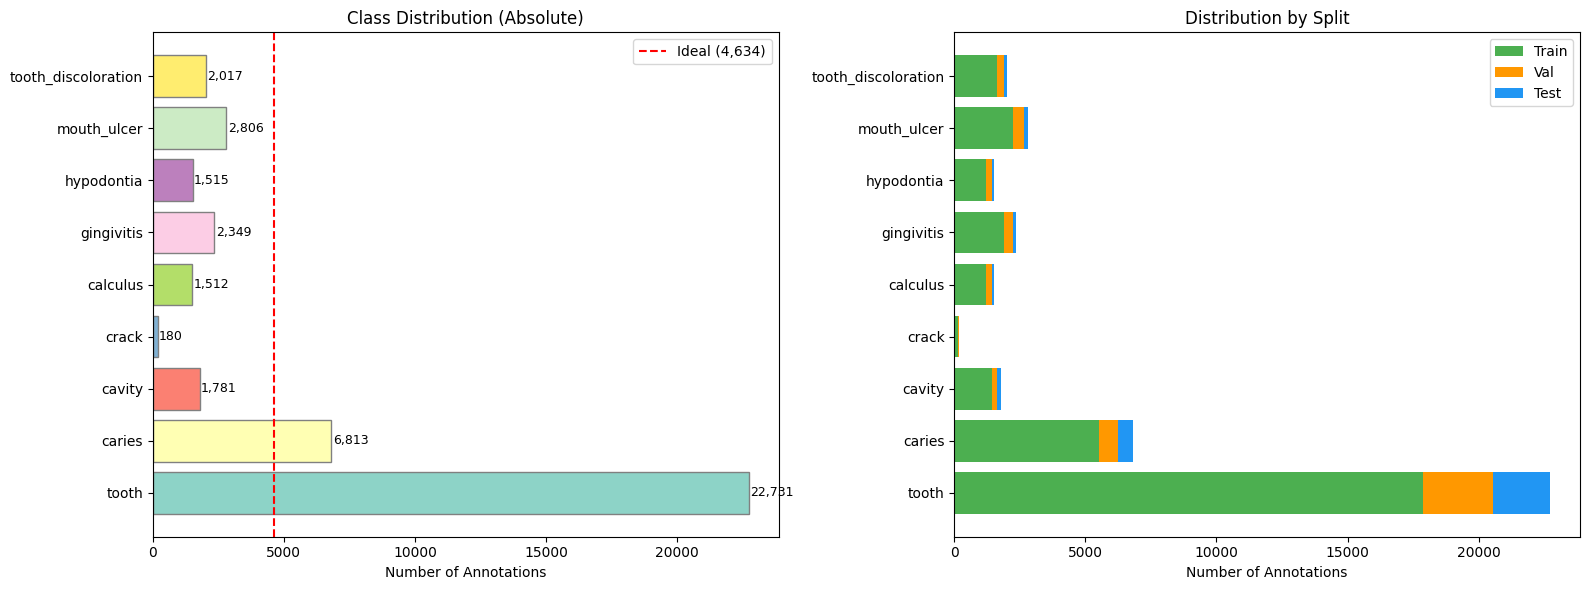

📊 Chart saved to class_balance_analysis.png


In [9]:
import yaml
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import defaultdict

MERGED_DIR = Path("./yolo_dataset_merged")

# Load config
with open(MERGED_DIR / "data.yaml") as f:
    config = yaml.safe_load(f)

NUM_CLASSES = config["nc"]
CLASS_NAMES = config["names"]

# ── Count annotations per class per split ────────────────────────────────
split_class_counts = {}
for split in ['train', 'val', 'test']:
    counts = defaultdict(int)
    lbl_dir = MERGED_DIR / split / "labels"
    if lbl_dir.exists():
        for lbl in lbl_dir.glob("*.txt"):
            for line in lbl.read_text().strip().splitlines():
                parts = line.strip().split()
                if parts:
                    try:
                        counts[int(parts[0])] += 1
                    except ValueError:
                        pass
    split_class_counts[split] = counts

# Combined counts
total_counts = defaultdict(int)
for counts in split_class_counts.values():
    for cid, cnt in counts.items():
        total_counts[cid] += cnt

total_annots = sum(total_counts.values())
ideal_per_class = total_annots / NUM_CLASSES if NUM_CLASSES else 0

# ── Print table ──────────────────────────────────────────────────────────
print("=" * 85)
print("CLASS BALANCE ANALYSIS")
print("=" * 85)
print(f"{'ID':<4} {'Class':<22} {'Train':>7} {'Val':>7} {'Test':>7} {'Total':>8} {'%':>7} {'Status'}")
print("-" * 85)

counts_list = []
for cid in range(NUM_CLASSES):
    name = CLASS_NAMES[cid]
    tr = split_class_counts['train'].get(cid, 0)
    va = split_class_counts['val'].get(cid, 0)
    te = split_class_counts['test'].get(cid, 0)
    tot = total_counts.get(cid, 0)
    pct = (tot / total_annots * 100) if total_annots else 0
    counts_list.append(tot)

    # Status assessment
    if tot == 0:
        status = "❌ MISSING"
    elif tot < ideal_per_class * 0.2:
        status = "🔴 SEVERELY UNDER"
    elif tot < ideal_per_class * 0.5:
        status = "🟠 UNDER-SAMPLED"
    elif tot > ideal_per_class * 3.0:
        status = "🔵 OVER-SAMPLED"
    elif tot > ideal_per_class * 2.0:
        status = "🟡 SLIGHTLY OVER"
    else:
        status = "✅ OK"

    print(f"{cid:<4} {name:<22} {tr:>7} {va:>7} {te:>7} {tot:>8} {pct:>6.1f}% {status}")

# ── Imbalance metrics ────────────────────────────────────────────────────
nonzero = [c for c in counts_list if c > 0]
if len(nonzero) >= 2:
    ratio = max(nonzero) / min(nonzero)
    std   = np.std(nonzero)
    mean  = np.mean(nonzero)
    cv    = std / mean * 100  # coefficient of variation
else:
    ratio, cv = 0, 0

print(f"\n{'─' * 85}")
print(f"  Total annotations:     {total_annots}")
print(f"  Ideal per class:       {ideal_per_class:,.0f}")
print(f"  Imbalance ratio:       {ratio:.1f}x  (max/min)")
print(f"  Coefficient of var:    {cv:.1f}%")

if ratio > 10:
    print(f"\n  ⚠️  SEVERE IMBALANCE ({ratio:.0f}x) — consider:")
    print(f"      • Oversampling minority classes (copy/augment)")
    print(f"      • Undersampling majority classes")
    print(f"      • Using class-weighted loss during training")
elif ratio > 3:
    print(f"\n  ⚠️  MODERATE IMBALANCE ({ratio:.1f}x) — augmentation may help")
else:
    print(f"\n  ✅ Reasonably balanced ({ratio:.1f}x)")

# ── Bar chart ────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Absolute counts
colors = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))
bars = ax1.barh(CLASS_NAMES, counts_list, color=colors, edgecolor='gray')
ax1.axvline(x=ideal_per_class, color='red', linestyle='--', label=f'Ideal ({ideal_per_class:,.0f})')
ax1.set_xlabel("Number of Annotations")
ax1.set_title("Class Distribution (Absolute)")
ax1.legend()
for bar, cnt in zip(bars, counts_list):
    ax1.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, f'{cnt:,}',
             va='center', fontsize=9)

# Per-split stacked
train_vals = [split_class_counts['train'].get(i, 0) for i in range(NUM_CLASSES)]
val_vals   = [split_class_counts['val'].get(i, 0) for i in range(NUM_CLASSES)]
test_vals  = [split_class_counts['test'].get(i, 0) for i in range(NUM_CLASSES)]

y_pos = np.arange(NUM_CLASSES)
ax2.barh(y_pos, train_vals, label='Train', color='#4CAF50')
ax2.barh(y_pos, val_vals,   left=train_vals, label='Val', color='#FF9800')
left2 = [t + v for t, v in zip(train_vals, val_vals)]
ax2.barh(y_pos, test_vals,  left=left2, label='Test', color='#2196F3')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(CLASS_NAMES)
ax2.set_xlabel("Number of Annotations")
ax2.set_title("Distribution by Split")
ax2.legend()

plt.tight_layout()
plt.savefig("class_balance_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved to class_balance_analysis.png")

## Step 6b — Class Balancing
Apply hybrid over/under-sampling **to training set only** (val/test are copied unchanged):
- **Undersample** `tooth`-only images to reduce dominance
- **Oversample** minority classes with image augmentation (flip, brightness, contrast, rotation)
- **Heavy augmentation** for `crack` (only 180 annotations → target ~3,000)
- Target: all classes between 3,000–5,000 annotations, ≤2x imbalance ratio

In [2]:
import shutil, random, yaml
import numpy as np
from pathlib import Path
from collections import defaultdict
from PIL import Image, ImageEnhance, ImageFilter

random.seed(42)
np.random.seed(42)

# ── Config ───────────────────────────────────────────────────────────────
SRC_DIR = Path("./yolo_dataset_merged")
BAL_DIR = Path("./yolo_dataset_balanced")
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Clean previous balanced dataset to avoid stale files
if BAL_DIR.exists():
    shutil.rmtree(BAL_DIR)
    print("🧹 Cleaned previous balanced dataset")

# Load class config from merged dataset
with open(SRC_DIR / "data.yaml") as f:
    config = yaml.safe_load(f)
NUM_CLASSES = config["nc"]
CLASS_NAMES = config["names"]

# Targets per class (annotations, not images — some images have multiple annotations)
TARGET_ANNOTATIONS = {
    0: 5000,   # tooth          — undersample from 22,731
    1: 5000,   # caries         — slight undersample from 6,813
    2: 3500,   # cavity         — oversample from 1,781
    3: 3000,   # crack          — heavy oversample from 180
    4: 3500,   # calculus       — oversample from 1,512
    5: 3500,   # gingivitis     — oversample from 2,349
    6: 3500,   # hypodontia     — oversample from 1,515
    7: 3500,   # mouth_ulcer    — slight oversample from 2,806
    8: 3500,   # tooth_discolor — oversample from 2,017
}

# ── Augmentation functions ───────────────────────────────────────────────
def augment_image(img_path, output_path, intensity="normal"):
    """Apply random augmentations and save. Returns True if horizontally flipped."""
    try:
        img = Image.open(img_path).convert("RGB")
    except Exception:
        shutil.copy(img_path, output_path)
        return True

    transforms = []

    if random.random() > 0.5:
        transforms.append("hflip")
    if random.random() > 0.4:
        transforms.append("brightness")
    if random.random() > 0.4:
        transforms.append("contrast")
    if random.random() > 0.5:
        transforms.append("rotate")

    if intensity == "heavy":
        transforms.extend(["color", "sharpness"])
        if random.random() > 0.3:
            transforms.append("blur")

    for t in transforms:
        if t == "hflip":
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        elif t == "brightness":
            img = ImageEnhance.Brightness(img).enhance(random.uniform(0.7, 1.4))
        elif t == "contrast":
            img = ImageEnhance.Contrast(img).enhance(random.uniform(0.7, 1.4))
        elif t == "rotate":
            img = img.rotate(random.uniform(-15, 15), fillcolor=(0, 0, 0), expand=False)
        elif t == "color":
            img = ImageEnhance.Color(img).enhance(random.uniform(0.7, 1.3))
        elif t == "sharpness":
            img = ImageEnhance.Sharpness(img).enhance(random.uniform(0.5, 2.0))
        elif t == "blur":
            img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 1.5)))

    img.save(output_path, quality=95)
    return "hflip" in transforms


def mirror_labels_horizontal(label_lines):
    """Mirror YOLO bounding box labels for a horizontal flip."""
    mirrored = []
    for line in label_lines:
        parts = line.strip().split()
        if len(parts) != 5:
            mirrored.append(line)
            continue
        cid, xc, yc, w, h = parts[0], float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        xc_new = 1.0 - xc
        mirrored.append(f"{cid} {xc_new:.6f} {yc:.6f} {w:.6f} {h:.6f}")
    return mirrored


def filter_labels_for_augmentation(label_lines, target_cid, running_counts, targets):
    """
    Filter label lines for augmented images to prevent co-occurring class inflation.
    
    - ALWAYS keeps annotations for the target class being oversampled
    - Only keeps co-occurring class annotations if that class is still below target
    - Returns filtered lines (never empty — at minimum keeps target class lines)
    """
    filtered = []
    for line in label_lines:
        parts = line.strip().split()
        if not parts:
            continue
        try:
            line_cid = int(parts[0])
        except ValueError:
            continue
        
        if line_cid == target_cid:
            # Always keep the class we're oversampling for
            filtered.append(line)
        elif running_counts.get(line_cid, 0) < targets.get(line_cid, 3500):
            # Keep co-occurring class only if it's still below its own target
            filtered.append(line)
        # else: skip — this co-occurring class is already at/above target
    
    return filtered if filtered else label_lines  # Fallback: keep all if filter removed everything


# ── Setup output dirs ────────────────────────────────────────────────────
for split in ['train', 'val', 'test']:
    (BAL_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (BAL_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

# ── Copy val & test unchanged ────────────────────────────────────────────
for split in ['val', 'test']:
    src_imgs = SRC_DIR / split / "images"
    src_lbls = SRC_DIR / split / "labels"
    if not src_imgs.exists():
        continue
    count = 0
    for img_path in sorted(src_imgs.iterdir()):
        if img_path.suffix.lower() not in VALID_EXTS:
            continue
        lbl_path = src_lbls / (img_path.stem + ".txt")
        if not lbl_path.exists():
            continue
        shutil.copy(img_path, BAL_DIR / split / "images" / img_path.name)
        shutil.copy(lbl_path, BAL_DIR / split / "labels" / lbl_path.name)
        count += 1
    print(f"📋 Copied {split}: {count} samples (unchanged)")

# ── Analyze training set ─────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print("ANALYZING TRAINING SET")
print("=" * 65)

train_img_dir = SRC_DIR / "train" / "images"
train_lbl_dir = SRC_DIR / "train" / "labels"

# Build index: for each image, which classes does it contain?
image_classes = {}   # stem -> set of class_ids
image_annots  = {}   # stem -> list of label lines
class_images  = defaultdict(list)  # class_id -> list of stems

for lbl_path in sorted(train_lbl_dir.glob("*.txt")):
    stem = lbl_path.stem
    lines = lbl_path.read_text().strip().splitlines()
    classes_in_image = set()
    for line in lines:
        parts = line.strip().split()
        if parts:
            try:
                classes_in_image.add(int(parts[0]))
            except ValueError:
                pass
    image_classes[stem] = classes_in_image
    image_annots[stem]  = lines
    for cid in classes_in_image:
        class_images[cid].append(stem)

# Count current annotations per class
current_counts = defaultdict(int)
for stem, lines in image_annots.items():
    for line in lines:
        parts = line.strip().split()
        if parts:
            try:
                current_counts[int(parts[0])] += 1
            except ValueError:
                pass

print("Current training annotations (merged dataset):")
for cid in range(NUM_CLASSES):
    target = TARGET_ANNOTATIONS.get(cid, 3500)
    arrow = "↓" if current_counts[cid] > target else "↑"
    print(f"  {cid}: {CLASS_NAMES[cid]:<22} {current_counts[cid]:>6} → {target:>5} {arrow}")

# ── Step A: Undersample tooth-only images ────────────────────────────────
print(f"\n{'=' * 65}")
print("STEP A: UNDERSAMPLE TOOTH-ONLY IMAGES")
print("=" * 65)

tooth_only_stems = [s for s, cls_set in image_classes.items() if cls_set == {0}]
tooth_mixed_stems = [s for s, cls_set in image_classes.items() if 0 in cls_set and len(cls_set) > 1]
non_tooth_stems   = [s for s, cls_set in image_classes.items() if 0 not in cls_set]

print(f"  Tooth-only images:  {len(tooth_only_stems)}")
print(f"  Tooth+damage imgs:  {len(tooth_mixed_stems)} (keep all — contain damage annotations)")
print(f"  Non-tooth images:   {len(non_tooth_stems)} (keep all)")

# Calculate how many tooth-only to keep
tooth_annots_from_mixed = sum(
    sum(1 for line in image_annots[s] if line.strip().split()[0] == '0')
    for s in tooth_mixed_stems
)
tooth_target = TARGET_ANNOTATIONS[0]
tooth_only_needed = max(0, tooth_target - tooth_annots_from_mixed)

if tooth_only_stems:
    avg_tooth_per_img = sum(len(image_annots[s]) for s in tooth_only_stems) / len(tooth_only_stems)
    n_tooth_only_keep = min(len(tooth_only_stems), max(50, int(tooth_only_needed / avg_tooth_per_img)))
else:
    n_tooth_only_keep = 0

random.shuffle(tooth_only_stems)
kept_tooth_only = tooth_only_stems[:n_tooth_only_keep]
dropped = len(tooth_only_stems) - n_tooth_only_keep

print(f"  Tooth annots from mixed images: {tooth_annots_from_mixed}")
print(f"  Keeping {n_tooth_only_keep}/{len(tooth_only_stems)} tooth-only images (dropping {dropped})")

base_stems = set(kept_tooth_only) | set(tooth_mixed_stems) | set(non_tooth_stems)
print(f"  Base training set: {len(base_stems)} images")

# ── Step B: Copy base set ────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print("STEP B: COPY BASE TRAINING SET")
print("=" * 65)

idx = 0
stem_to_balanced_name = {}

for stem in sorted(base_stems):
    img_candidates = list(train_img_dir.glob(f"{stem}.*"))
    img_path = None
    for c in img_candidates:
        if c.suffix.lower() in VALID_EXTS:
            img_path = c
            break
    if img_path is None:
        continue

    new_name = f"bal_{idx:06d}"
    shutil.copy(img_path, BAL_DIR / "train" / "images" / f"{new_name}{img_path.suffix}")
    (BAL_DIR / "train" / "labels" / f"{new_name}.txt").write_text("\n".join(image_annots[stem]))
    stem_to_balanced_name[stem] = new_name
    idx += 1

print(f"  Copied {idx} base training images")

# ── Recount after undersampling ──────────────────────────────────────────
running_counts = defaultdict(int)
for stem in base_stems:
    for line in image_annots.get(stem, []):
        parts = line.strip().split()
        if parts:
            try:
                running_counts[int(parts[0])] += 1
            except ValueError:
                pass

print("\n  After undersampling:")
for cid in range(NUM_CLASSES):
    target = TARGET_ANNOTATIONS.get(cid, 3500)
    status = "✅" if running_counts[cid] <= target * 1.2 else f"⚠️ {running_counts[cid]/target:.1f}x target"
    print(f"    {cid}: {CLASS_NAMES[cid]:<22} {running_counts[cid]:>6}  (target: {target})  {status}")

# ── Step C: Oversample minority classes (WITH FILTERED LABELS) ───────────
print(f"\n{'=' * 65}")
print("STEP C: OVERSAMPLE MINORITY CLASSES")
print("=" * 65)
print("  ℹ️  Using filtered labels: co-occurring classes above target are stripped")
print("     from augmented labels to prevent cascading inflation.\n")

aug_idx = idx  # Continue numbering

for cid in range(NUM_CLASSES):
    current = running_counts[cid]
    target  = TARGET_ANNOTATIONS[cid]

    if current >= target:
        print(f"  {CLASS_NAMES[cid]:<22} {current:>6} >= {target} — skip")
        continue

    needed = target - current
    source_stems = [s for s in class_images[cid] if s in base_stems]

    if not source_stems:
        print(f"  {CLASS_NAMES[cid]:<22} — no source images! skip")
        continue

    intensity = "heavy" if cid == 3 else "normal"
    multiplier = needed / max(1, current)

    print(f"  {CLASS_NAMES[cid]:<22} {current:>6} → {target} (need +{needed}, ~{multiplier:.1f}x, {intensity})")

    generated = 0
    attempts = 0
    max_attempts = needed * 3

    while generated < needed and attempts < max_attempts:
        stem = random.choice(source_stems)
        img_candidates = list(train_img_dir.glob(f"{stem}.*"))
        img_path = None
        for c in img_candidates:
            if c.suffix.lower() in VALID_EXTS:
                img_path = c
                break
        if img_path is None:
            attempts += 1
            continue

        new_name = f"aug_{aug_idx:06d}"
        out_img  = BAL_DIR / "train" / "images" / f"{new_name}{img_path.suffix}"

        was_flipped = augment_image(img_path, out_img, intensity=intensity)

        # Get labels (mirror if flipped)
        label_lines = image_annots[stem]
        if was_flipped:
            label_lines = mirror_labels_horizontal(label_lines)

        # ── KEY FIX: Filter labels to prevent co-occurring class inflation ──
        # Only keep annotations for the target class + any class still below target
        filtered_lines = filter_labels_for_augmentation(
            label_lines, cid, running_counts, TARGET_ANNOTATIONS
        )
        (BAL_DIR / "train" / "labels" / f"{new_name}.txt").write_text("\n".join(filtered_lines))

        aug_idx += 1
        generated += 1
        attempts += 1

        # Update running counts using FILTERED lines only (not original)
        for l in filtered_lines:
            p = l.strip().split()
            if p:
                try:
                    running_counts[int(p[0])] += 1
                except ValueError:
                    pass

    print(f"    → Generated {generated} augmented images")

total_balanced = aug_idx
print(f"\n  Total balanced training images: {total_balanced}")

# ── Write data.yaml ──────────────────────────────────────────────────────
bal_abs = str(BAL_DIR.resolve())
yaml_content = f"""train: {bal_abs}/train/images
val: {bal_abs}/val/images
test: {bal_abs}/test/images

nc: {NUM_CLASSES}
names: {CLASS_NAMES}
"""
(BAL_DIR / "data.yaml").write_text(yaml_content)

# ── Final count ──────────────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print("FINAL BALANCED DISTRIBUTION (train only)")
print("=" * 65)

final_counts = defaultdict(int)
for lbl in (BAL_DIR / "train" / "labels").glob("*.txt"):
    for line in lbl.read_text().strip().splitlines():
        parts = line.strip().split()
        if parts:
            try:
                final_counts[int(parts[0])] += 1
            except ValueError:
                pass

total_final = sum(final_counts.values())
nonzero = [c for c in final_counts.values() if c > 0]
final_ratio = max(nonzero) / min(nonzero) if len(nonzero) >= 2 and min(nonzero) > 0 else 0

print(f"\n  {'Class':<22} {'Before':>8} {'After':>8} {'Target':>8} {'Change':>8} {'%':>6}  Status")
print(f"  {'-'*78}")
for cid in range(NUM_CLASSES):
    before = current_counts[cid]
    after  = final_counts.get(cid, 0)
    target = TARGET_ANNOTATIONS[cid]
    pct    = after / total_final * 100 if total_final else 0
    change = after - before
    change_str = f"+{change}" if change >= 0 else f"{change}"
    
    if after > target * 1.5:
        status = "⚠️ OVER"
    elif after < target * 0.8:
        status = "🔴 UNDER"
    else:
        status = "✅"
    
    print(f"  {CLASS_NAMES[cid]:<22} {before:>8} {after:>8} {target:>8} {change_str:>8} {pct:>5.1f}%  {status}")

print(f"\n  Total annotations: {total_final}")
print(f"  Imbalance ratio:   {final_ratio:.1f}x (was {max(current_counts.values())/max(1,min(v for v in current_counts.values() if v>0)):.1f}x)")
print(f"\n✅ Balanced dataset saved to: {BAL_DIR}")

for split in ['train', 'val', 'test']:
    n = len(list((BAL_DIR / split / "images").glob("*")))
    print(f"   {split:>5}: {n} images")

KeyboardInterrupt: 

---
## Step 7 — Train YOLOv8 Model
Train on the **balanced** dataset (`yolo_dataset_balanced/data.yaml`).

In [ ]:
# Cell: Part 3 - Train the Model

from ultralytics import YOLO
from pathlib import Path
import os
import torch

# ============================================
# CONFIGURATION
# ============================================

# Path to your data.yaml file — MUST use balanced dataset!
DATA_YAML = str(Path("yolo_dataset_balanced/data.yaml").resolve())
assert Path(DATA_YAML).exists(), f"❌ Balanced dataset not found at {DATA_YAML}! Run Part 2 first."
print(f"📂 Dataset: {DATA_YAML}")

# Auto-detect device
DEVICE = 0 if torch.cuda.is_available() else "cpu"
print(f"🖥️  Using device: {'GPU (CUDA)' if DEVICE == 0 else 'CPU'}")
if DEVICE == "cpu":
    print("   ⚠️  Training on CPU will be very slow. GPU recommended.")

# Training hyperparameters
CONFIG = {
    "model": "yolov8m.pt",    # Use MEDIUM model for 9-class problem (more capacity)
    "epochs": 200,             # 200 epochs for thorough training
    "batch_size": 16,          # Reduce to 8 if out-of-memory with yolov8m
    "img_size": 640,
    "patience": 50,            # ← FIXED: was 20, now 50 — gives model time to learn rare classes
    "lr0": 0.001,
    "device": DEVICE,
}

print(f"\n⚙️  Training config:")
print(f"   Model:    {CONFIG['model']} (medium — better for multi-class)")
print(f"   Epochs:   {CONFIG['epochs']}")
print(f"   Patience: {CONFIG['patience']} (early stop after {CONFIG['patience']} epochs w/o improvement)")
print(f"   Batch:    {CONFIG['batch_size']}")
print(f"   LR:       {CONFIG['lr0']}")

# ============================================
# OPTIONAL: Weights & Biases Tracking
# ============================================
USE_WANDB = False  # Set to True if you want W&B logging

if USE_WANDB:
    try:
        import wandb
        wandb.init(
            project="Dental_Detection",
            name="YOLOv8_Tooth_and_Damage",
            config=CONFIG
        )
    except ImportError:
        print("⚠️  wandb not installed, skipping experiment tracking")
        USE_WANDB = False

# ============================================
# LOAD PRE-TRAINED MODEL
# ============================================
print(f"\nLoading pre-trained model: {CONFIG['model']}")
model = YOLO(CONFIG["model"])

print(f"\nModel info:")
print(f"  Parameters: {sum(p.numel() for p in model.model.parameters()):,}")

# ============================================
# TRAIN THE MODEL
# ============================================
print(f"\n{'='*60}")
print("STARTING TRAINING")
print(f"{'='*60}")
print(f"  Dataset:  yolo_dataset_balanced")
print(f"  Epochs:   {CONFIG['epochs']}  |  Patience: {CONFIG['patience']}")
print(f"  Model:    {CONFIG['model']}")
print(f"{'='*60}\n")

try:
    results = model.train(
        data=DATA_YAML,
        epochs=CONFIG["epochs"],
        batch=CONFIG["batch_size"],
        imgsz=CONFIG["img_size"],
        patience=CONFIG["patience"],

        project="Dental_Detection",
        name="YOLOv8_Training",
        exist_ok=True,
        save_period=10,

        # Data augmentation
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        degrees=10.0,
        translate=0.1,
        scale=0.3,
        flipud=0.0,       # Dental X-rays: vertical flip usually harmful
        fliplr=0.5,
        mosaic=0.8,
        mixup=0.1,

        optimizer='AdamW',
        lr0=CONFIG["lr0"],
        weight_decay=0.0005,
        device=CONFIG["device"],
        val=True,
    )

    print(f"\n{'='*60}")
    print("TRAINING COMPLETED!")
    print(f"{'='*60}\n")

    # ============================================
    # BEST MODEL PATH (use this everywhere)
    # ============================================
    BEST_MODEL_PATH = str(Path("Dental_Detection/YOLOv8_Training/weights/best.pt"))
    MODEL_PATH = BEST_MODEL_PATH  # Global reference for later cells

    if Path(BEST_MODEL_PATH).exists():
        print(f"✅ Best model saved at: {BEST_MODEL_PATH}")
    else:
        # Fallback to last.pt
        LAST_MODEL_PATH = str(Path("Dental_Detection/YOLOv8_Training/weights/last.pt"))
        MODEL_PATH = LAST_MODEL_PATH
        print(f"✅ Model saved at: {LAST_MODEL_PATH}")

    # ============================================
    # PRINT FINAL METRICS
    # ============================================
    print("\nFinal Training Results:")
    print(f"  Best mAP50:    {results.results_dict.get('metrics/mAP50(B)', 'N/A')}")
    print(f"  Best mAP50-95: {results.results_dict.get('metrics/mAP50-95(B)', 'N/A')}")

finally:
    if USE_WANDB:
        try:
            wandb.finish()
        except:
            pass

🖥️  Using device: CPU
   ⚠️  Training on CPU will be very slow. GPU recommended.
Loading pre-trained model: yolov8s.pt

Model info:
  Parameters: 11,166,560

STARTING TRAINING

New https://pypi.org/project/ultralytics/8.4.14 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.12  Python-3.14.2 torch-2.10.0+cpu CPU (AMD Ryzen 7 5700G with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\PerezKylerLee(Studen\SmileGuard-Train\yolo_dataset\data.yaml, degrees=10.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v

KeyboardInterrupt: 

In [ ]:
# Cell: Part 4 - DentalDetector Class

from ultralytics import YOLO
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import numpy as np

class DentalDetector:
    """
    Dental Detection System
    
    Detects:
    - Teeth (generic tooth class)
    - Damage: caries, cavity, crack
    - Position: upper/lower, left/right (heuristic from bbox)
    """
    
    def __init__(self, model_path):
        """
        Initialize the detector
        
        Args:
            model_path: Path to trained YOLOv8 model (.pt file)
        """
        print(f"Loading model from: {model_path}")
        self.model = YOLO(model_path)
        
        # Read class names from the model itself
        self.class_names = self.model.names  # dict: {0: 'tooth', 1: 'caries', ...}
        
        # Categorize classes based on what the model actually knows
        self.tooth_classes = []
        self.damage_classes = []
        
        known_damage = {'caries', 'cavity', 'crack', 'decay'}
        known_teeth = {'tooth', 'incisor', 'canine', 'premolar', 'molar'}
        
        for class_id, class_name in self.class_names.items():
            lower_name = class_name.lower()
            if lower_name in known_teeth:
                self.tooth_classes.append(class_name)
            elif lower_name in known_damage:
                self.damage_classes.append(class_name)
            else:
                print(f"  ⚠️  Unknown class '{class_name}' (id={class_id}) — treating as damage")
                self.damage_classes.append(class_name)
        
        print("✅ Model loaded successfully!")
        print(f"   Model classes: {list(self.class_names.values())}")
        print(f"   Tooth classes: {self.tooth_classes}")
        print(f"   Damage classes: {self.damage_classes}")
    
    def determine_position(self, bbox, img_height):
        """
        Determine if detection is in upper or lower jaw.
        
        Note: This is a simple heuristic based on image midpoint.
        It works best with standardized dental X-ray framing.
        For production use, consider a separate jaw segmentation model.
        """
        y_center = (bbox[1] + bbox[3]) / 2
        return 'upper' if y_center < img_height / 2 else 'lower'
    
    def determine_side(self, bbox, img_width):
        """Determine if detection is on left or right side."""
        x_center = (bbox[0] + bbox[2]) / 2
        return 'left' if x_center < img_width / 2 else 'right'
    
    def detect(self, image_path, conf_threshold=0.5, iou_threshold=0.45):
        """
        Perform detection on an image.
        
        Args:
            image_path: Path to the input image
            conf_threshold: Confidence threshold (0-1)
            iou_threshold: IoU threshold for NMS
            
        Returns:
            dict with 'teeth' and 'damages' detections
        """
        results = self.model(
            image_path,
            conf=conf_threshold,
            iou=iou_threshold,
            verbose=False
        )
        
        img = Image.open(image_path)
        img_width, img_height = img.size
        
        teeth = []
        damages = []
        
        for result in results:
            boxes = result.boxes
            
            for box in boxes:
                class_id = int(box.cls.cpu().numpy())
                class_name = result.names[class_id]
                confidence = float(box.conf.cpu().numpy())
                bbox = box.xyxy[0].cpu().numpy().tolist()
                
                position = self.determine_position(bbox, img_height)
                side = self.determine_side(bbox, img_width)
                
                detection = {
                    'class': class_name,
                    'class_id': class_id,
                    'confidence': round(confidence, 4),
                    'bbox': [round(c, 2) for c in bbox],
                    'position': position,
                    'side': side,
                    'full_label': f"{position} {side} {class_name}"
                }
                
                if class_name in self.tooth_classes:
                    teeth.append(detection)
                else:
                    damages.append(detection)
        
        return {
            'teeth': teeth,
            'damages': damages,
            'image_path': str(image_path),
            'image_size': (img_width, img_height)
        }
    
    def visualize(self, image_path, detections, save_path=None):
        """Visualize detections on the image."""
        img = Image.open(image_path).convert("RGB")
        draw = ImageDraw.Draw(img)
        
        try:
            font = ImageFont.truetype("arial.ttf", 16)
        except:
            font = ImageFont.load_default()
        
        # Color map for different classes
        colors = {
            'tooth': "#00FF00",
            'caries': "#FF0000",
            'cavity': "#FF6600",
            'crack': "#FF00FF",
        }
        
        # Draw teeth (green boxes)
        for tooth in detections['teeth']:
            bbox = tooth['bbox']
            color = colors.get(tooth['class'], "#00FF00")
            
            draw.rectangle(bbox, outline=color, width=3)
            
            label = f"{tooth['full_label']} {tooth['confidence']:.0%}"
            text_bbox = draw.textbbox((bbox[0], bbox[1] - 25), label, font=font)
            draw.rectangle(text_bbox, fill=color)
            draw.text((bbox[0], bbox[1] - 25), label, fill="#000000", font=font)
        
        # Draw damages (red/orange boxes)
        for damage in detections['damages']:
            bbox = damage['bbox']
            color = colors.get(damage['class'], "#FF0000")
            
            draw.rectangle(bbox, outline=color, width=3)
            
            label = f"{damage['class'].upper()} {damage['confidence']:.0%}"
            text_bbox = draw.textbbox((bbox[0], bbox[1] - 25), label, font=font)
            draw.rectangle(text_bbox, fill=color)
            draw.text((bbox[0], bbox[1] - 25), label, fill="#FFFFFF", font=font)
        
        plt.figure(figsize=(15, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.title(
            f"Detected: {len(detections['teeth'])} teeth, {len(detections['damages'])} damages",
            fontsize=16, fontweight='bold'
        )
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"✅ Visualization saved to: {save_path}")
        
        plt.show()
        return img
    
    def get_patient_report(self, detections):
        """Generate a human-readable patient report."""
        report = []
        report.append("=" * 60)
        report.append("           DENTAL DETECTION REPORT")
        report.append("=" * 60)
        report.append("")
        
        # Teeth summary
        report.append(f"🦷 TEETH DETECTED: {len(detections['teeth'])}")
        report.append("-" * 60)
        
        if not detections['teeth']:
            report.append("  No teeth detected in this image.")
        else:
            for i, tooth in enumerate(detections['teeth'], 1):
                report.append(
                    f"  {i}. {tooth['position'].capitalize()} {tooth['side']} "
                    f"{tooth['class']} (confidence: {tooth['confidence']:.1%})"
                )
        
        report.append("")
        report.append("=" * 60)
        
        # Damage summary
        report.append(f"⚠️  DAMAGE DETECTED: {len(detections['damages'])}")
        report.append("-" * 60)
        
        if not detections['damages']:
            report.append("  ✅ No damage detected! Teeth appear healthy.")
        else:
            for i, damage in enumerate(detections['damages'], 1):
                report.append(
                    f"  {i}. {damage['class'].upper()} on {damage['position']} {damage['side']} area"
                )
                report.append(f"     Confidence: {damage['confidence']:.1%}")
                report.append("")
        
        report.append("=" * 60)
        report.append("")
        report.append("NOTE: This is an AI-assisted screening tool.")
        report.append("Please consult a dental professional for diagnosis.")
        report.append("=" * 60)
        
        return "\n".join(report)
    
    def batch_detect(self, image_paths, conf_threshold=0.5):
        """Detect on multiple images."""
        results = []
        for i, img_path in enumerate(image_paths, 1):
            print(f"Processing [{i}/{len(image_paths)}]: {img_path}")
            detections = self.detect(img_path, conf_threshold)
            results.append(detections)
        return results

print("✅ DentalDetector class loaded successfully!")

In [ ]:
# Cell: Part 5 - Test the Model (Inference)

# ============================================
# LOAD THE TRAINED MODEL
# ============================================

# Use best.pt from training (set in Part 3), or override here:
if 'MODEL_PATH' not in dir() or not Path(MODEL_PATH).exists():
    MODEL_PATH = "Dental_Detection/YOLOv8_Training/weights/best.pt"

print(f"Using model: {MODEL_PATH}")
detector = DentalDetector(MODEL_PATH)

# ============================================
# TEST ON A SINGLE IMAGE
# ============================================

# Replace with your test image path
TEST_IMAGE = "yolo_dataset/test/images"  # UPDATE THIS to a specific image!

# Check if it's a directory — pick the first image
test_path = Path(TEST_IMAGE)
if test_path.is_dir():
    test_files = list(test_path.glob("*.jpg")) + list(test_path.glob("*.png"))
    if test_files:
        TEST_IMAGE = str(test_files[0])
        print(f"Auto-selected test image: {TEST_IMAGE}")
    else:
        raise FileNotFoundError(f"No images found in {TEST_IMAGE}")

# Perform detection
detections = detector.detect(
    TEST_IMAGE,
    conf_threshold=0.5
)

# Print report
print(detector.get_patient_report(detections))

# Visualize results
detector.visualize(
    TEST_IMAGE,
    detections,
    save_path="detection_result.jpg"
)

In [ ]:
# Cell: Part 8 - Model Evaluation

from ultralytics import YOLO
from pathlib import Path

# Load the trained model
model = YOLO(MODEL_PATH)

# Validate on test set
print("Evaluating model on test set...")
metrics = model.val(
    data=DATA_YAML,
    split='test',
    conf=0.5,
    iou=0.45
)

# Print overall metrics
print("\n" + "="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)
print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")
print(f"\nInference speed: {metrics.speed['inference']:.1f}ms per image")

# Per-class metrics
print("\n" + "="*60)
print("PER-CLASS PERFORMANCE")
print("="*60)
print(f"{'Class':<15} {'Precision':<12} {'Recall':<12} {'mAP50':<12} {'mAP50-95':<12}")
print("-" * 63)

class_names = model.names
ap50_per_class = metrics.box.ap50       # shape: (num_classes,)
ap_per_class = metrics.box.ap           # shape: (num_classes,) — mean over IoU thresholds
p_per_class = metrics.box.p             # per-class precision
r_per_class = metrics.box.r             # per-class recall

for i, name in class_names.items():
    if i < len(ap50_per_class):
        print(
            f"{name:<15} "
            f"{p_per_class[i]:<12.4f} "
            f"{r_per_class[i]:<12.4f} "
            f"{ap50_per_class[i]:<12.4f} "
            f"{ap_per_class[i]:<12.4f}"
        )

In [ ]:
# Cell: Part 10 - Flask API for Integration

# Save this code to a separate file (e.g., app.py) and run it

flask_code = '''
from flask import Flask, request, jsonify
from PIL import Image
import io
import base64
import tempfile
import os

# Import DentalDetector (copy the class or import from a module)
from ultralytics import YOLO

app = Flask(__name__)

# Initialize detector
MODEL_PATH = "Dental_Detection/YOLOv8_Training/weights/best.pt"
model = YOLO(MODEL_PATH)

# Read class names from model
tooth_classes = set()
damage_classes = set()
known_damage = {"caries", "cavity", "crack", "decay"}
known_teeth = {"tooth", "incisor", "canine", "premolar", "molar"}

for cid, cname in model.names.items():
    if cname.lower() in known_teeth:
        tooth_classes.add(cname)
    else:
        damage_classes.add(cname)


@app.route("/detect", methods=["POST"])
def detect_dental():
    """
    API endpoint for dental detection.

    Expected input (JSON):
    {
        "image": "base64_encoded_image_string",
        "confidence": 0.5  // optional
    }
    """
    try:
        data = request.json
        image_data = base64.b64decode(data["image"])
        conf = data.get("confidence", 0.5)

        # Save to a unique temp file (thread-safe)
        with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
            tmp_path = tmp.name
            img = Image.open(io.BytesIO(image_data))
            img.save(tmp_path)

        try:
            # Run detection
            results = model(tmp_path, conf=conf, iou=0.45, verbose=False)
            img_w, img_h = img.size

            teeth = []
            damages = []

            for result in results:
                for box in result.boxes:
                    class_id = int(box.cls.cpu().numpy())
                    class_name = result.names[class_id]
                    confidence = float(box.conf.cpu().numpy())
                    bbox = box.xyxy[0].cpu().numpy().tolist()

                    y_center = (bbox[1] + bbox[3]) / 2
                    x_center = (bbox[0] + bbox[2]) / 2
                    position = "upper" if y_center < img_h / 2 else "lower"
                    side = "left" if x_center < img_w / 2 else "right"

                    det = {
                        "class": class_name,
                        "confidence": round(confidence, 4),
                        "bbox": [round(c, 2) for c in bbox],
                        "position": position,
                        "side": side,
                    }

                    if class_name in tooth_classes:
                        teeth.append(det)
                    else:
                        damages.append(det)

            return jsonify({
                "success": True,
                "teeth": teeth,
                "damages": damages,
                "summary": {
                    "total_teeth": len(teeth),
                    "total_damages": len(damages),
                    "has_damage": len(damages) > 0,
                },
            })

        finally:
            os.unlink(tmp_path)

    except Exception as e:
        return jsonify({"success": False, "error": str(e)}), 500


@app.route("/health", methods=["GET"])
def health_check():
    return jsonify({"status": "healthy", "model": "loaded", "classes": list(model.names.values())})


if __name__ == "__main__":
    app.run(debug=True, host="0.0.0.0", port=5000)
'''

# Write the Flask app to a file
with open("app.py", "w") as f:
    f.write(flask_code)

print("✅ Flask API saved to: app.py")
print("   Run with: python app.py")
print("   API will be available at: http://localhost:5000")
print("   Endpoints:")
print("     POST /detect  - Detect teeth and damage in an image")
print("     GET  /health  - Health check")

---
## Summary & Next Steps

### What This Notebook Does:
1. ✅ Prepares dental dataset in YOLO format
2. ✅ Trains YOLOv8 to detect tooth types (incisors, canines, molars, premolars)
3. ✅ Trains YOLOv8 to detect damage (caries, cavity, decay, crack)
4. ✅ Provides position detection (upper/lower, left/right)
5. ✅ Generates patient reports
6. ✅ Includes API integration example

### Your Checklist:
- [ ] Prepare dataset with tooth type annotations
- [ ] Run Part 1 (dataset preparation)
- [ ] Run Part 3 (model training - 1-3 hours)
- [ ] Run Part 5 (test inference)
- [ ] Run Part 8 (evaluate performance)
- [ ] Integrate into your application using Part 10

### Tips for Better Results:
1. **More data is better**: Aim for 1000+ images
2. **Diverse images**: Different lighting, angles, cameras
3. **Accurate annotations**: Double-check your labels
4. **Higher epochs**: Try 150-200 epochs for better accuracy
5. **Larger model**: Use YOLOv8l or YOLOv8x if accuracy is critical

### Troubleshooting:
- **Low accuracy**: Need more training data or longer training
- **False positives**: Increase confidence threshold to 0.6-0.7
- **Out of memory**: Reduce batch size to 8 or 4
- **Slow training**: Use smaller model (yolov8n) or reduce image size

### Resources:
- Dataset labeling: https://roboflow.com or https://labelstud.io
- YOLOv8 docs: https://docs.ultralytics.com
- Dental datasets: Search Roboflow Universe, Kaggle

---

**Good luck with your dental detection project! 🦷**